In [1]:
import cv2
import os
import numpy as np
import tensorflow as tf
from sklearn.model_selection import train_test_split
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout, BatchNormalization
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint
from sklearn.neighbors import KNeighborsClassifier
import matplotlib.pyplot as plt
import heapq

In [2]:
# Paths to train and test folders
train_folder_path = r"C:\Users\Shash\Desktop\Hackathon+  Projects\Indian Birds Classification\Birds_Dataset\train"
test_folder_path = r"C:\Users\Shash\Desktop\Hackathon+  Projects\Indian Birds Classification\Birds_Dataset\valid"

In [3]:
# Dictionary to map class names (bird names) to numerical labels
label_dict = {}

# Function to load images and labels
def load_images_from_folder(folder_path, image_paths_list, labels_list, label_dict):
    for bird_name in os.listdir(folder_path):
        bird_folder = os.path.join(folder_path, bird_name)
        if os.path.isdir(bird_folder):
            if bird_name not in label_dict:
                label_dict[bird_name] = len(label_dict)
            for filename in os.listdir(bird_folder):
                if filename.endswith('.jpg') or filename.endswith('.png'):
                    image_paths_list.append(os.path.join(bird_folder, filename))
                    labels_list.append(label_dict[bird_name])

In [4]:
# Load training and testing data
train_image_paths, train_labels = [], []
test_image_paths, test_labels = [], []

load_images_from_folder(train_folder_path, train_image_paths, train_labels, label_dict)
load_images_from_folder(test_folder_path, test_image_paths, test_labels, label_dict)

In [5]:
# Preprocess images function
def preprocess_image(image_path):
    image = cv2.imread(image_path)
    if image is not None:
        image = cv2.resize(image, (64, 64))
        image = image / 255.0
        return image
    else:
        return np.zeros((64, 64, 3))

In [6]:
# Preprocess training and testing images
train_images = np.array([preprocess_image(path) for path in train_image_paths])
test_images = np.array([preprocess_image(path) for path in test_image_paths])
train_labels = np.array(train_labels)
test_labels = np.array(test_labels)

In [7]:
# Using ImageDataGenerator for data augmentation
datagen = ImageDataGenerator(
    rotation_range=20,
    width_shift_range=0.2,
    height_shift_range=0.2,
    shear_range=0.2,
    zoom_range=0.2,
    horizontal_flip=True,
    fill_mode='nearest'
)

In [8]:
# Model definition with Batch Normalization
model = Sequential([
    Conv2D(32, (3, 3), activation='relu', input_shape=(64, 64, 3)),
    BatchNormalization(),
    MaxPooling2D(pool_size=(2, 2)),
    Conv2D(64, (3, 3), activation='relu'),
    BatchNormalization(),
    MaxPooling2D(pool_size=(2, 2)),
    Conv2D(128, (3, 3), activation='relu'),
    BatchNormalization(),
    MaxPooling2D(pool_size=(2, 2)),
    Flatten(),
    Dense(256, activation='relu'),
    Dropout(0.5),
    Dense(len(label_dict), activation='softmax')
])

c:\Users\Shash\AppData\Local\Programs\Python\Python312\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [9]:
# Compile the model with a lower learning rate
model.compile(optimizer=Adam(learning_rate=0.001), loss='sparse_categorical_crossentropy', metrics=['accuracy'])

In [10]:
# Callbacks for early stopping and saving the best model
callbacks = [
    EarlyStopping(monitor='val_loss', patience=5, verbose=1),
    ModelCheckpoint('best_model.keras', monitor='val_accuracy', save_best_only=True, verbose=1)
]

In [11]:
# Train the model with augmented data
model.fit(datagen.flow(train_images, train_labels, batch_size=32),
          validation_data=(test_images, test_labels),
          epochs=20,
          callbacks=callbacks)

Epoch 1/20


c:\Users\Shash\AppData\Local\Programs\Python\Python312\Lib\site-packages\keras\src\trainers\data_adapters\py_dataset_adapter.py:122: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


938/938 ━━━━━━━━━━━━━━━━━━━━ 0s 175ms/step - accuracy: 0.0774 - loss: 3.2973
Epoch 1: val_accuracy improved from -inf to 0.16373, saving model to best_model.keras
938/938 ━━━━━━━━━━━━━━━━━━━━ 185s 192ms/step - accuracy: 0.0774 - loss: 3.2970 - val_accuracy: 0.1637 - val_loss: 2.6575
Epoch 2/20
938/938 ━━━━━━━━━━━━━━━━━━━━ 0s 180ms/step - accuracy: 0.1199 - loss: 2.7780
Epoch 2: val_accuracy improved from 0.16373 to 0.22813, saving model to best_model.keras
938/938 ━━━━━━━━━━━━━━━━━━━━ 176s 187ms/step - accuracy: 0.1200 - loss: 2.7780 - val_accuracy: 0.2281 - val_loss: 2.4081
Epoch 3/20
938/938 ━━━━━━━━━━━━━━━━━━━━ 0s 157ms/step - accuracy: 0.1652 - loss: 2.6254
Epoch 3: val_accuracy improved from 0.22813 to 0.23400, saving model to best_model.keras
938/938 ━━━━━━━━━━━━━━━━━━━━ 153s 163ms/step - accuracy: 0.1652 - loss: 2.6254 - val_accuracy: 0.2340 - val_loss: 2.3636
Epoch 4/20
938/938 ━━━━━━━━━━━━━━━━━━━━ 0s 157ms/step - accuracy: 0.2051 - loss: 2.4935
Epoch 4: val_accuracy improved f

In [12]:
# Evaluate the model on the test set
val_loss, val_accuracy = model.evaluate(test_images, test_labels)
print(f'Validation Accuracy: {val_accuracy * 100:.2f}%')

235/235 ━━━━━━━━━━━━━━━━━━━━ 10s 40ms/step - accuracy: 0.6721 - loss: 1.0814
Validation Accuracy: 68.65%


In [13]:
# KNN Classification using scikit-learn
knn_model = KNeighborsClassifier(n_neighbors=3)
train_images_flat = train_images.reshape(len(train_images), -1)
test_images_flat = test_images.reshape(len(test_images), -1)

In [14]:
# Train KNN model
knn_model.fit(train_images_flat, train_labels)

KNeighborsClassifier(n_neighbors=3)

In [15]:
# Test KNN on the first test image
knn_prediction = knn_model.predict([test_images_flat[0]])
print(f"KNN predicted label: {knn_prediction[0]}, Actual label: {test_labels[0]}")

KNN predicted label: 0, Actual label: 0


235/235 ━━━━━━━━━━━━━━━━━━━━ 9s 32ms/step


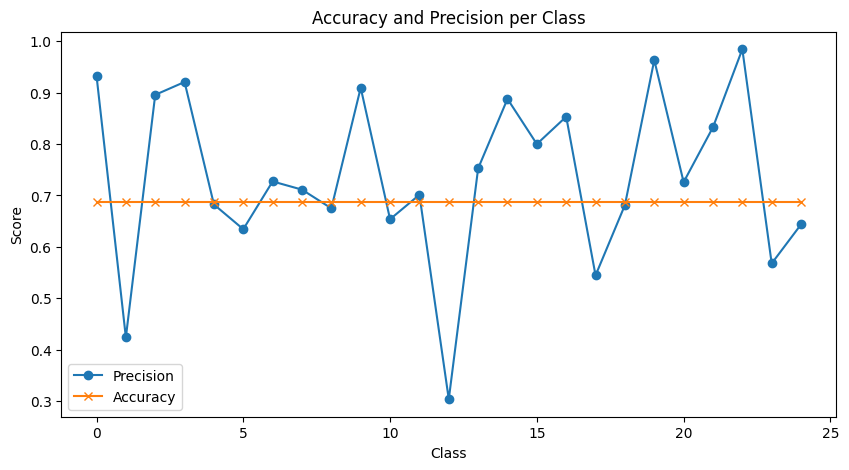

In [16]:
from sklearn.metrics import classification_report

# Get the predictions for the test set
test_predictions = model.predict(test_images)
test_predictions_labels = np.argmax(test_predictions, axis=1)

# Generate the classification report
report = classification_report(test_labels, test_predictions_labels, output_dict=True)

# Extract precision values for each class
precision_values = [report[str(i)]['precision'] for i in range(len(label_dict))]

# Extract accuracy values (we already have val_accuracy)
accuracy_values = [val_accuracy] * len(label_dict)

# Plotting the graph
plt.figure(figsize=(10, 5))
plt.plot(range(len(label_dict)), precision_values, label='Precision', marker='o')
plt.plot(range(len(label_dict)), accuracy_values, label='Accuracy', marker='x')
plt.xlabel('Class')
plt.ylabel('Score')
plt.title('Accuracy and Precision per Class')
plt.legend()
plt.show()

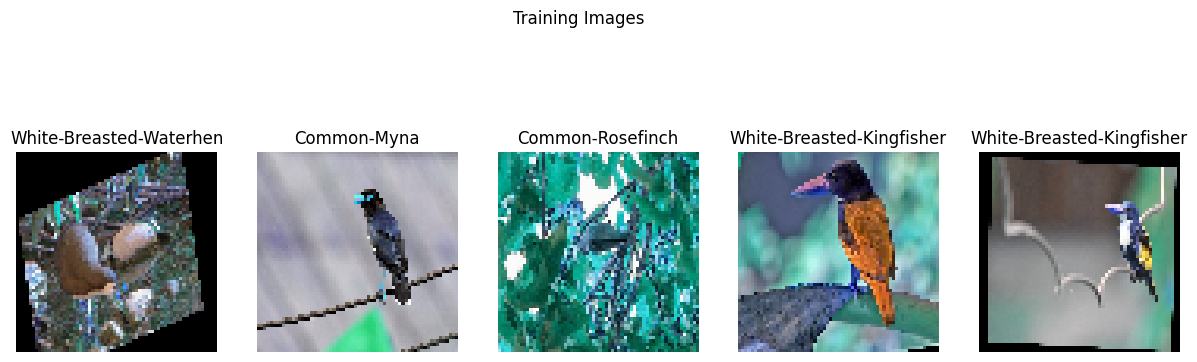

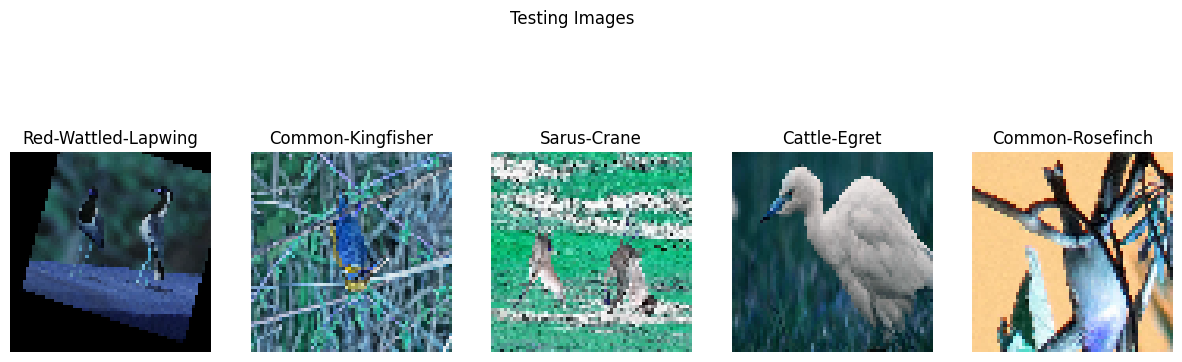

In [17]:
import random

def plot_images(images, labels, label_dict, title, num_images=5):
    plt.figure(figsize=(15, 5))
    indices = random.sample(range(len(images)), num_images)
    for i, index in enumerate(indices):
        plt.subplot(1, num_images, i + 1)
        plt.imshow(images[index])
        plt.title(list(label_dict.keys())[list(label_dict.values()).index(labels[index])])
        plt.axis('off')
    plt.suptitle(title)
    plt.show()

# Plot training images with labels
plot_images(train_images, train_labels, label_dict, 'Training Images')

# Plot testing images with labels
plot_images(test_images, test_labels, label_dict, 'Testing Images')

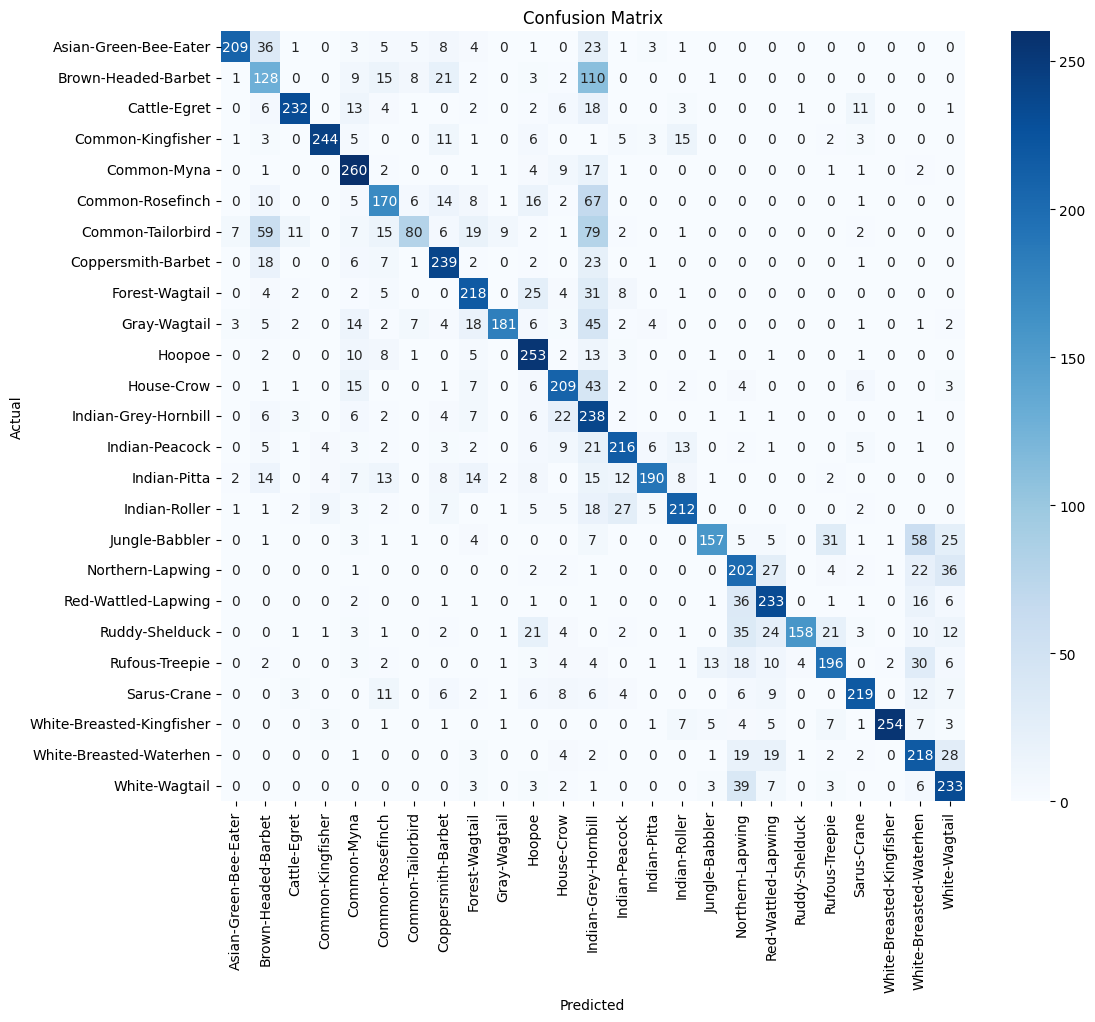

In [18]:
from sklearn.metrics import confusion_matrix
import seaborn as sns

# Compute confusion matrix
conf_matrix = confusion_matrix(test_labels, test_predictions_labels)

# Plot confusion matrix
plt.figure(figsize=(12, 10))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues', xticklabels=label_dict.keys(), yticklabels=label_dict.keys())
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

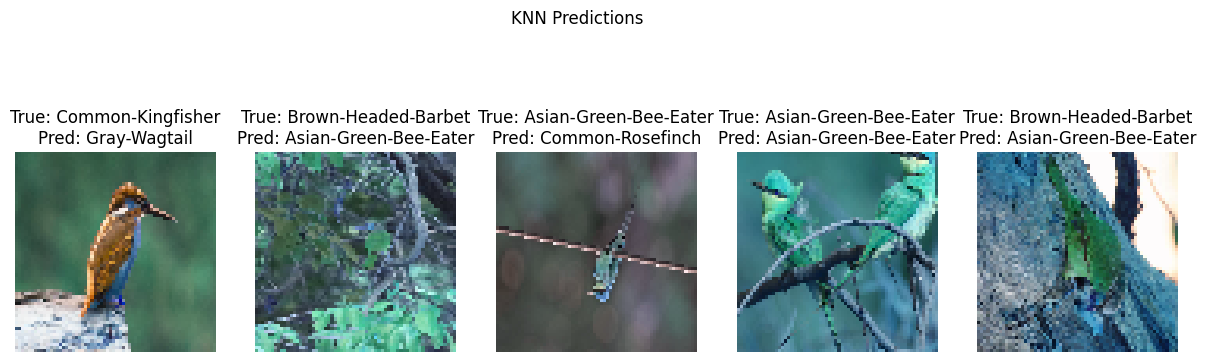

In [19]:
def plot_knn_predictions(images, true_labels, predicted_labels, label_dict, num_images=5):
    plt.figure(figsize=(15, 5))
    indices = random.sample(range(len(images)), num_images)
    for i, index in enumerate(indices):
        plt.subplot(1, num_images, i + 1)
        plt.imshow(images[index])
        true_label = list(label_dict.keys())[list(label_dict.values()).index(true_labels[index])]
        predicted_label = list(label_dict.keys())[list(label_dict.values()).index(predicted_labels[index])]
        plt.title(f'True: {true_label}\nPred: {predicted_label}')
        plt.axis('off')
    plt.suptitle('KNN Predictions')
    plt.show()

# Get KNN predictions for a subset of test images
knn_predictions_subset = knn_model.predict(test_images_flat[:1000])

# Plot KNN predictions
plot_knn_predictions(test_images[:1000], test_labels, knn_predictions_subset, label_dict)